# Figures Section 2
Here, the figures corresponding to the section on immune cell single cell data in the final report will be generated

## Imports

In [2]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [3]:
### Directories and Files ###
root = '../../'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = f'{root}Generated Data/Final Report/Section 2/'
metadata_dir = f"{root}Data/sc_data/cell_types.tsv"
figure_save_dir = f"{root}Generated Data/Final Report/Section 2/Final Figures/"

In [4]:
### Imports ###
import sys
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_ot_optim, subset_clr_data, generate_clustermap, generate_umap, long_transform, generate_marginal_plot, hic_ot_bulk_threshold_sequential, generate_violin_plot
from time import perf_counter
from itertools import combinations
from matplotlib.patches import Rectangle

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
### Importing data ###
clrs = import_cool_dir(data_dir)
metadata_df = pd.read_csv(metadata_dir, sep="\t")
outlier_data = pd.read_csv(f"{root}Generated Data/Single-to-single/sc_uot_clustering/OT/RandomSubsets/unbalanced_reg_m=0.1_cluster_1mb_95_20_seed=42.csv", index_col=0)

## Panel B + F
Clustermap with balanced OT data

### Generating Data
For now, this will be with a smaller subset. Eventually, this should all be replaced with more cells being considered.

In [ ]:
local_save_dir = f'{save_dir}Main Figure/Panel B/'

    # Subset
balanced_subset = subset_clr_data(
    data_dir,
    metadata_df,
    40
)

    # OT
balanced_results = hic_ot_optim(
    balanced_subset,
    "chr1",
    "threshold",
    "sum",
    thres=95,
    thres_type="percentile"
)

    # Saving
balanced_results.to_csv(f'{local_save_dir}subset_ot_seed=42_count=40_res=1mb_thres=95.csv')

<string>:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
100%|██████████| 42778/42778 [00:42<00:00, 1010.93it/s]


In [14]:
# Loading
balanced_immune_dir = f"{root}Generated Data/Server/immune_balanced_chr1_count=100_res=1_thres=95.csv"
balanced_results = pd.read_csv(balanced_immune_dir, index_col=0)

In [15]:
balanced_results

,arc_pair_100024,arc_pair_10713,arc_pair_108969,arc_pair_109120,arc_pair_109177,arc_pair_104224,arc_pair_109701,arc_pair_110541,arc_pair_112778,arc_pair_11307,...,arc_pair_91267,arc_pair_9539,arc_pair_91549,arc_pair_91641,arc_pair_96327,arc_pair_96822,arc_pair_92168,arc_pair_97861,arc_pair_92584,arc_pair_92850
arc_pair_100024,0.000000,1752.890746,430.503784,574.332432,2005.113999,2636.806274,2200.251714,3320.434979,467.307458,411.340568,...,1473.160568,867.952695,535.776714,1403.093853,319.688596,629.232447,1723.855577,2032.423643,578.460342,557.739225
arc_pair_10713,1752.890746,0.000000,1595.682409,2912.374543,336.777459,1228.916544,897.597126,6861.413708,1700.519855,1162.134994,...,4334.188757,626.185235,1635.079999,317.911628,1990.182796,866.275450,4500.413167,5121.589174,2366.287996,2772.806403
arc_pair_108969,430.503784,1595.682409,0.000000,1250.397183,2119.400740,3338.620591,2801.627465,4416.839740,124.452535,316.890807,...,1736.412264,870.415816,135.294499,1227.365582,636.201098,414.788992,2176.578831,2866.755719,439.229549,765.606115
arc_pair_109120,574.332432,2912.374543,1250.397183,0.000000,3192.191939,3529.953679,3083.822826,2204.070070,1125.039239,1330.520703,...,781.145674,1920.652736,1321.645342,2525.824976,1030.797471,1623.096886,900.356728,1070.927619,725.997331,317.887324
arc_pair_109177,2005.113999,336.777459,2119.400740,3192.191939,0.000000,794.586637,664.632300,7389.164189,2173.164755,1493.415998,...,4999.796517,871.437823,2043.897136,580.973449,2326.592254,1188.751599,5169.712408,5496.720790,2947.641717,3278.510494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
arc_pair_96822,629.232447,866.275450,414.788992,1623.096886,1188.751599,2233.969982,1838.961358,4923.441948,504.954973,216.230245,...,2495.763652,299.173519,458.469092,524.718354,695.575656,0.000000,2842.843667,3414.635444,1032.385547,1313.213405
arc_pair_92168,1723.855577,4500.413167,2176.578831,900.356728,5169.712408,5515.385359,4869.883338,1503.782397,2004.590777,2495.126962,...,194.482974,3312.235041,2369.361121,4033.197655,2079.586426,2842.843667,0.000000,665.626463,1488.499578,961.369275
arc_pair_97861,2032.423643,5121.589174,2866.755719,1070.927619,5496.720790,5643.606240,5015.187546,774.739084,2693.127279,3125.890251,...,831.214212,3849.448472,3012.824479,4596.878348,2402.315114,3414.635444,665.626463,0.000000,2141.987205,1468.948877
arc_pair_92584,578.460342,2366.287996,439.229549,725.997331,2947.641717,3913.044997,3316.226384,3538.938403,343.942908,798.377822,...,1118.555840,1507.285095,531.473086,1964.960747,924.527988,1032.385547,1488.499578,2141.987205,0.000000,338.944986


In [7]:
### Loading and long transform ###
balanced_results_long = long_transform(balanced_results, metadata_df)

### Clustermap

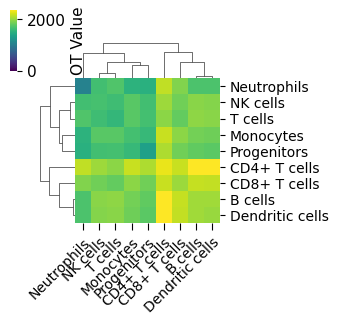

In [8]:
generate_clustermap(
    balanced_results_long,
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(3.4,3.4),
    cbar_pos=(-0.04, 0.87, 0.02, 0.18),
    textsize=11
)
plt.savefig(f"{figure_save_dir}F2B.pdf", bbox_inches='tight')

### UMAP

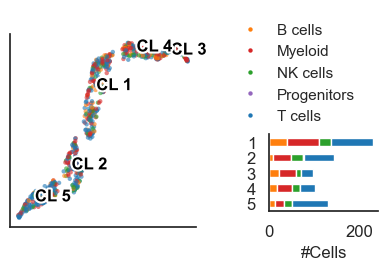

In [39]:
cell_mapping = {
        "B cells": "B cells",
        "CD4+ T cells": "T cells",
        "CD8+ T cells": "T cells",
        "T cells": "T cells",
        "NK cells": "NK cells",
        "Dendritic cells": "Myeloid",
        "Monocytes": "Myeloid",
        "Neutrophils": "Myeloid",
        "Progenitors": "Progenitors"
    }

colors = {
    "T cells": "#1f77b4",
    "B cells": "#ff7f0e",
    "NK cells": "#2ca02c",
    "Myeloid": "#d62728",
    "Progenitors": "#9467bd"
}

embed = generate_umap(
    balanced_results,
    metadata_df,
    group_map=cell_mapping,
    palette=colors,
    n_cluster=5,
    barchart=True,
    figsize=(3.5,2.5),
    bar_size=[0.8, -0.05, 1.8, 0.4],
    dot_size=10,
    alpha=0.6)
plt.savefig(f"{figure_save_dir}F2F.pdf", bbox_inches='tight')

## Panel C
Marginal plot of UOT data with outliers

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


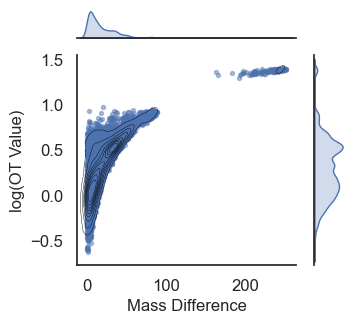

In [20]:
outlier_data_long = long_transform(outlier_data, metadata_df)
mass_file = pd.read_csv(f"{root}Generated Data/Single-to-single/sc_uot_clustering/OT/Metadata/1mb_95_maxnorm_total_mass.csv", index_col=0)
generate_marginal_plot(outlier_data_long, mass_file, textsize=12, figsize=(3.7, 3.4))
plt.savefig(f"{figure_save_dir}F2C.pdf", bbox_inches='tight')

## Panel D
UOT clustermap

In [16]:
# Loading data
unbalanced_immune_dir = f"{root}Generated Data/Server/immune_unbalanced_chr1_count=100_res=1_thres=95_reg_m=0.1.csv"
unbalanced_results = pd.read_csv(unbalanced_immune_dir, index_col=0)
unbalanced_results_long = long_transform(unbalanced_results, metadata_df)

In [17]:
unbalanced_results

,arc_pair_100024,arc_pair_10713,arc_pair_108969,arc_pair_109120,arc_pair_109177,arc_pair_104224,arc_pair_109701,arc_pair_110541,arc_pair_112778,arc_pair_11307,...,arc_pair_91267,arc_pair_9539,arc_pair_91549,arc_pair_91641,arc_pair_96327,arc_pair_96822,arc_pair_92168,arc_pair_97861,arc_pair_92584,arc_pair_92850
arc_pair_100024,0.000000,2.183815,2.685078,2.658899,3.236564,2.419584,2.682603,2.351510,2.420687,2.423422,...,2.389011,2.442029,2.168092,2.440997,2.808063,3.473154,2.621256,4.714194,2.636262,2.159157
arc_pair_10713,2.183815,0.000000,1.137145,1.944656,1.578871,1.069154,1.116558,1.537474,0.720201,1.338159,...,1.367345,0.709344,0.814429,1.356273,0.930384,2.872544,0.909708,3.461474,0.943085,1.729972
arc_pair_108969,2.685078,1.137145,0.000000,2.242449,1.670391,1.327808,1.403759,2.068959,0.815715,0.870550,...,1.275207,0.982562,0.906903,0.852346,1.096376,2.147645,1.060932,3.954552,0.834895,1.788546
arc_pair_109120,2.658899,1.944656,2.242449,0.000000,2.390897,1.994945,2.148340,2.266267,1.751959,1.855667,...,2.077305,1.927226,1.761783,2.072059,2.081713,3.032528,2.056139,3.821259,1.822084,2.359144
arc_pair_109177,3.236564,1.578871,1.670391,2.390897,0.000000,1.432991,1.165896,1.786517,0.899910,1.487941,...,1.566185,1.215231,1.217397,1.497644,0.729758,4.090623,1.108179,4.140686,0.875132,2.777796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
arc_pair_96822,3.473154,2.872544,2.147645,3.032528,4.090623,3.271481,3.501587,3.770462,2.994621,2.429124,...,2.910456,2.842985,2.593655,2.639137,3.428863,0.000000,3.169918,5.091838,2.929850,2.834889
arc_pair_92168,2.621256,0.909708,1.060932,2.056139,1.108179,1.175700,0.990024,1.389889,0.647913,1.163331,...,1.111057,0.854898,0.790792,1.134565,0.542427,3.169918,0.000000,3.523211,0.449530,2.260553
arc_pair_97861,4.714194,3.461474,3.954552,3.821259,4.140686,3.683227,3.754503,3.765231,3.584099,3.655051,...,3.714568,3.618506,3.580267,3.997204,3.619478,5.091838,3.523211,0.000000,3.668705,4.317896
arc_pair_92584,2.636262,0.943085,0.834895,1.822084,0.875132,1.060746,0.705870,1.529895,0.523856,0.969065,...,1.059555,0.642515,0.519250,0.825547,0.407951,2.929850,0.449530,3.668705,0.000000,2.112772


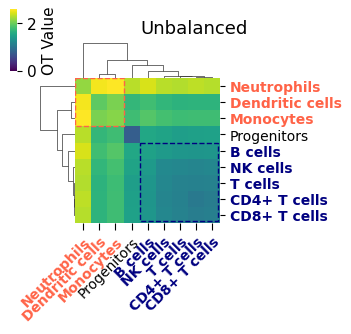

In [101]:
# Generating clustermap
g = generate_clustermap(
    unbalanced_results_long,
    vmin=0,
    cbar_kws={'label' : 'OT Value'},
    figsize=(3.4,3.4),
    cbar_pos=(-0.04, 0.87, 0.02, 0.18),
    textsize=11,
    title="Unbalanced"
)

# Drawing myeloid and lymphoid blocks
    # Defining blocks
lymphoid = ["B cells", "NK cells", "T cells", "CD4+ T cells", "CD8+ T cells"]
myeloid = ["Neutrophils", "Dendritic cells", "Monocytes"]

    # Extracting indices from clustermap
reordered = g.data2d.index.tolist()

    # Position of lymphoid cells
pos_lymph = [reordered.index(x) for x in lymphoid if x in reordered]
pos_myeloid = [reordered.index(x) for x in myeloid if x in reordered]

    # Positions for block
start_lymph = min(pos_lymph)
end_lymph = max(pos_lymph)
start_myeloid = min(pos_myeloid)
end_myeloid = max(pos_myeloid)
    
    # Drawing rectangles
ax = g.ax_heatmap

rect_lymph = Rectangle(
    (start_lymph, start_lymph),
    width= end_lymph - start_lymph + 0.88,
    height= end_lymph - start_lymph + 0.88,
    fill=False,
    edgecolor="navy",
    linewidth=1,
    linestyle="--"
)

rect_myeloid = Rectangle(
    (start_myeloid, start_myeloid),
    width= end_myeloid - start_myeloid + 1,
    height= end_myeloid - start_myeloid + 1,
    fill=False,
    edgecolor="tomato",
    linewidth=1,
    linestyle="--"
)

ax.add_patch(rect_lymph)
ax.add_patch(rect_myeloid)

# Changing colors of labels to match to rectangles
for x_tick, y_tick in zip(ax.get_xticklabels(), ax.get_yticklabels()):

    label = x_tick.get_text()

    if label in lymphoid:
        x_tick.set_color("navy")
        x_tick.set_fontweight("bold")
        y_tick.set_color("navy")
        y_tick.set_fontweight("bold")

    elif label in myeloid:
        x_tick.set_color("tomato")
        x_tick.set_fontweight("bold")
        y_tick.set_color("tomato")
        y_tick.set_fontweight("bold")

plt.savefig(f"{figure_save_dir}F2D.pdf", bbox_inches='tight')

## Panel E
UOT UMAP

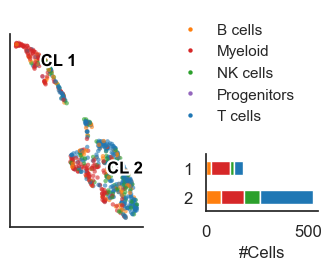

In [43]:
cell_mapping = {
        "B cells": "B cells",
        "CD4+ T cells": "T cells",
        "CD8+ T cells": "T cells",
        "T cells": "T cells",
        "NK cells": "NK cells",
        "Dendritic cells": "Myeloid",
        "Monocytes": "Myeloid",
        "Neutrophils": "Myeloid",
        "Progenitors": "Progenitors"
    }

colors = {
    "T cells": "#1f77b4",
    "B cells": "#ff7f0e",
    "NK cells": "#2ca02c",
    "Myeloid": "#d62728",
    "Progenitors": "#9467bd"
}

embed = generate_umap(
    unbalanced_results,
    metadata_df,
    group_map = cell_mapping,
    palette=colors,
    figsize=(2.5,2.5),
    bar_size=[1.05, -0.05, 2.6, 0.3],
    dot_size=10,
    alpha=0.6
)
plt.savefig(f"{figure_save_dir}F2E.pdf", bbox_inches='tight')

## Supplementary Figure 1
Correspondence between methods for single cell immune data.

### Helper Functions

In [19]:
### Helper function for importing data ###
def import_data_sup1(dir: str, balanced: bool=True) -> dict[str, pd.DataFrame]:
    '''
        Imports OT data (balanced or unbalanced) for section 2, supplementary
        figure 1 as a dictionary with resolution and threshold as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        balanced : bool
            Determines whether data to be imported is balanced.
            Default = True.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "[res] Mb, τ=[thres]".
    '''
    # Setting patterns
    if balanced:
        pattern = os.path.join(dir, "balanced_IMMUNE_SF1_res=*_thres=*_count=2.csv")
        regex = r"balanced_IMMUNE_SF1_res=(?P<res>.+?)_thres=(?P<thres>.+?)_count=2\.csv"
    else:
        pattern = os.path.join(dir, "unbalanced_IMMUNE_SF1_res=*_thres=*_reg_m=0.1_count=2.csv")
        regex = r"unbalanced_IMMUNE_SF1_res=(?P<res>.+?)_thres=(?P<thres>.+?)_reg_m=0\.1_count=2\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            res = match.group("res")
            thres  = match.group("thres")
            key = f"{res} Mb, τ={thres}%"
            data_dict[key] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

In [20]:
### Helper function for correspondences ###
def correspondence_matrix(results: dict[str, pd.DataFrame]) -> pd.DataFrame:
    '''
        Takes OT results in a dict given with resolution
        and threshold as keys and returns a dataframe
        giving linear correspondence between all methods.

        Parameters
        ----------
        results : dict[str, pd.DataFrame]
            Results imported as a dict by import_data_sup1.
            
        Returns
        -------
        cor_mat : pd.DataFrame
            Symmetric dataframe giving Pearson r2 between upper
            triangles
    '''
    keys = list(results.keys())
    n    = len(keys)

    # Extract upper triangles
    triags = {}
    for key, df in results.items():
        matrix = df.values
        idx = np.triu_indices(matrix.shape[0], k=1)  # k=1 excludes the diagonal
        triags[key] = matrix[idx].astype(float)
    
    # Correspondence matrix
    cor_mat = pd.DataFrame(np.ones((n, n)), index=keys, columns=keys)

    for key_a, key_b in combinations(keys, 2):
        vec_a = triags[key_a]
        vec_b = triags[key_b]

        r = np.corrcoef(vec_a, vec_b)[0, 1]
        r_squared = r ** 2

        cor_mat.loc[key_a, key_b] = r_squared
        cor_mat.loc[key_b, key_a] = r_squared 
    
    return cor_mat

### Generating Data

In [21]:
### Setting parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 2/Supplementary Figure 1/"
binning_factors = [8, 4, 2, 1]
thresholds = [95, 90, 75, 50, 0]
subset_sf1 = subset_clr_data(
    data_dir,
    metadata_df,
    2
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [12]:
### Balanced ###
time_path = f"{local_save_dir}section2_sf1_ot_balanced_times.csv"

for factor in binning_factors:
    for thres in thresholds:
        print(f"OT FOR RES={factor}, THRES={thres}")
        if not os.path.exists(f"{local_save_dir}balanced_IMMUNE_SF1_res={factor}_thres={thres}_count=2.csv"):
            time = perf_counter()

            # OT
            results = hic_ot_bulk_threshold_sequential(
                subset_sf1, 
                "chr1",
                norm="sum",
                thres=thres,
                thres_type="percentile",
                rebin_factor=factor)

            # Updating time file
            time = perf_counter() - time

                # Cast to strings to ensure proper indexing
            res_str = str(factor)
            thres_str = str(thres)

                # Make or import csv
            if os.path.exists(time_path):
                df_calc = pd.read_csv(time_path, index_col=0)
                df_calc.index = df_calc.index.astype(str)
            else:
                df_calc = pd.DataFrame()

                # Insert value in row
            df_calc.at[thres_str, res_str] = time

                # Save to CSV
            df_calc.to_csv(time_path)
            
            results.to_csv(f"{local_save_dir}balanced_IMMUNE_SF1_res={factor}_thres={thres}_count=2.csv")

OT FOR RES=8, THRES=95
OT FOR RES=8, THRES=90
OT FOR RES=8, THRES=75
OT FOR RES=8, THRES=50


100%|██████████| 153/153 [00:16<00:00,  9.23it/s]


OT FOR RES=8, THRES=0
OT FOR RES=4, THRES=95
OT FOR RES=4, THRES=90
OT FOR RES=4, THRES=75
OT FOR RES=4, THRES=50


100%|██████████| 153/153 [00:19<00:00,  7.95it/s]


OT FOR RES=4, THRES=0
OT FOR RES=2, THRES=95
OT FOR RES=2, THRES=90
OT FOR RES=2, THRES=75
OT FOR RES=2, THRES=50


100%|██████████| 153/153 [00:35<00:00,  4.32it/s]


OT FOR RES=2, THRES=0
OT FOR RES=1, THRES=95
OT FOR RES=1, THRES=90
OT FOR RES=1, THRES=75
OT FOR RES=1, THRES=50


100%|██████████| 153/153 [02:50<00:00,  1.12s/it]

OT FOR RES=1, THRES=0


In [9]:
### Unbalanced ###
time_path = f"{local_save_dir}section2_sf1_ot_unbalanced_times.csv"

for factor in binning_factors:
    for thres in thresholds:
        print(f"OT FOR RES={factor}, THRES={thres}")
        if not os.path.exists(f"{local_save_dir}unbalanced_IMMUNE_SF1_res={factor}_thres={thres}_reg_m=0.1_count=2.csv"):
            time = perf_counter()

            # OT
            results = hic_ot_bulk_threshold_sequential(
                subset_sf1, 
                "chr1",
                norm="max",
                thres=thres,
                thres_type="percentile",
                unbalanced=0.1,
                rebin_factor=factor)

            # Updating time file
            time = perf_counter() - time

                # Cast to strings to ensure proper indexing
            res_str = str(factor)
            thres_str = str(thres)

                # Make or import csv
            if os.path.exists(time_path):
                df_calc = pd.read_csv(time_path, index_col=0)
                df_calc.index = df_calc.index.astype(str)
            else:
                df_calc = pd.DataFrame()

                # Insert value in row
            df_calc.at[thres_str, res_str] = time

                # Save to CSV
            df_calc.to_csv(time_path)
            
            results.to_csv(f"{local_save_dir}unbalanced_IMMUNE_SF1_res={factor}_thres={thres}_reg_m=0.1_count=2.csv")

OT FOR RES=1, THRES=50


  1%|          | 1/153 [01:35<4:01:00, 95.14s/it]


KeyboardInterrupt: 

### Panel A+B
Times for resolutions and thresholds

In [22]:
### Getting number of comparisons to convert to time per comparison
results_shape = import_data_sup1(local_save_dir)["1 Mb, τ=0%"].shape[0]
n_comparisons = (results_shape ** 2 - results_shape) / 2

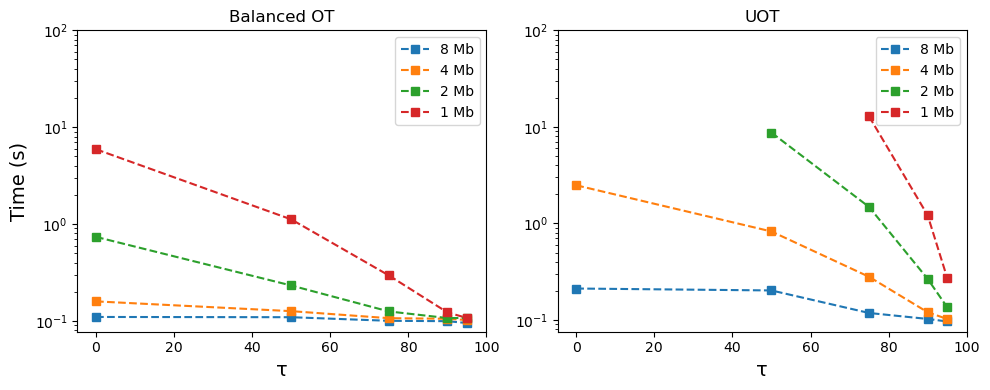

In [23]:
# Importing times
plt.rcdefaults()
time_path = f"{local_save_dir}section2_sf1_ot_balanced_times.csv"
time_path_unbalanced = f"{local_save_dir}section2_sf1_ot_unbalanced_times.csv"
times_s2balanced = pd.read_csv(time_path, index_col=0).sort_index(ascending=True)
times_s2unbalanced = pd.read_csv(time_path_unbalanced, index_col=0).sort_index(ascending=True)
res_list = ["8", "4", "2", "1"]
labels = [
    "8 Mb",
    "4 Mb",
    "2 Mb",
    "1 Mb"
]

# Initialize Figure
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Figure Balanced
for res in res_list:
    ax[0].plot(times_s2balanced[res].index, times_s2balanced[res]/n_comparisons, linestyle='--', marker='s')
ax[0].set_yscale('log')
ax[0].legend(labels=labels)
ax[0].set_xlabel("τ", size=14)
ax[0].set_ylabel("Time (s)", size=14)
ax[0].set_ylim(top=1e2)
ax[0].set_xlim(right=100)
ax[0].set_title("Balanced OT")

# Figure Unbalanced
for res in res_list:
    ax[1].plot(times_s2unbalanced[res].index, times_s2unbalanced[res]/n_comparisons, linestyle='--', marker='s')
ax[1].set_yscale('log')
ax[1].set_xlabel("τ", size=14)
ax[1].legend(labels=labels)
ax[1].set_ylim(top=1e2)
ax[1].set_xlim(right=100)
ax[1].set_title("UOT")
plt.tight_layout()
plt.savefig(f"{figure_save_dir}SF3AB.pdf", bbox_inches='tight')

### Panels C+D
Clustermaps for resolutions and thresholds

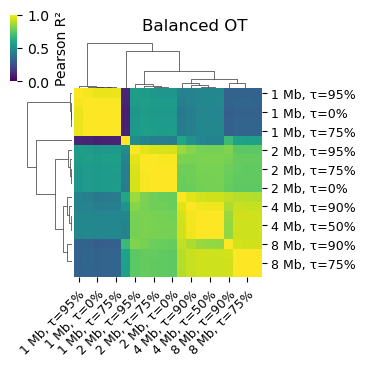

In [51]:
# Balanced
results_balanced = import_data_sup1(local_save_dir)
cor_mat_balanced = correspondence_matrix(results_balanced)
g = sns.clustermap(
    cor_mat_balanced,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)

# Label formatting
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Set tick label sizes
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=9)

# Colorbar size
g.cax.tick_params(labelsize=10)
g.cax.set_ylabel("Pearson R²", fontsize=10)

# Axis Labels
g.ax_heatmap.set_xlabel(g.ax_heatmap.get_xlabel(), fontsize=9)
g.ax_heatmap.set_ylabel(g.ax_heatmap.get_ylabel(), fontsize=9)

# Figure title
g.figure.suptitle("Balanced OT", y=1.02, fontsize=12)

plt.savefig(f"{figure_save_dir}SF3C.pdf", bbox_inches='tight')

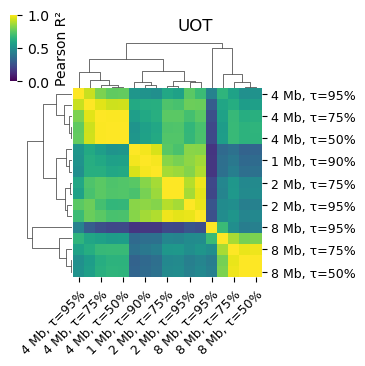

In [52]:
# Unbalanced
results_unbalanced = import_data_sup1(local_save_dir, False)
cor_mat_unbalanced = correspondence_matrix(results_unbalanced)
g = sns.clustermap(
    cor_mat_unbalanced,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)

# Label formatting
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Set tick label sizes
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=9)

# Colorbar size
g.cax.tick_params(labelsize=10)
g.cax.set_ylabel("Pearson R²", fontsize=10)

# Axis Labels
g.ax_heatmap.set_xlabel(g.ax_heatmap.get_xlabel(), fontsize=9)
g.ax_heatmap.set_ylabel(g.ax_heatmap.get_ylabel(), fontsize=9)

# Figure title
g.figure.suptitle("UOT", y=1.02, fontsize=12)

plt.savefig(f"{figure_save_dir}SF3D.pdf", bbox_inches='tight')

## Supplementary Figure 2
Correspondence between different reg_m values for unbalanced OT

### Helper Functions

In [306]:
### Helper function for importing data ###
def import_data_sup2(dir: str) -> dict[str, pd.DataFrame]:
    '''
        Imports OT data for section 2, supplementary
        figure 2 as a dictionary with reg_m as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "reg_m={reg_m}".
    '''
    # Setting patterns
    pattern = os.path.join(dir, "unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m=*_count=2.csv")
    regex = r"unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m=(?P<reg_m>\d*\.?\d+)_count=2.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            reg_m = match.group("reg_m")
            key = f"reg_m={reg_m}"
            data_dict[key] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

### Generating Data

In [318]:
### Setting parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 2/Supplementary Figure 2/"
reg_m_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]
subset_sf2 = subset_clr_data(
    data_dir,
    metadata_df,
    2
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [ ]:
time_path = f"{local_save_dir}section2_sf2_ot_reg_m_times.csv"
for reg_m in reg_m_list:
    print(f"OT FOR REG_M={reg_m}")
    if not os.path.exists(f"{local_save_dir}unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m={reg_m}_count=2.csv"):
        time = perf_counter()

        # OT
        results = hic_ot_optim(
            subset_sf2, 
            "chr1",
            selection="threshold",
            norm="max",
            thres=95,
            thres_type="percentile",
            unbalanced=reg_m,
            rebin_factor=1)

        # Updating time file
        time = perf_counter() - time

            # Cast to strings to ensure proper indexing
        res_str = "1 Mb, 95%"
        reg_m_str = str(reg_m)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[reg_m_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)
        
        results.to_csv(f"{local_save_dir}unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m={reg_m}_count=2.csv")

OT FOR REG_M=0.001
OT FOR REG_M=0.01
OT FOR REG_M=0.1
OT FOR REG_M=1.0


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [00:22<00:00,  6.76it/s]


OT FOR REG_M=10.0


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [00:23<00:00,  6.46it/s]


OT FOR REG_M=100.0


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [00:23<00:00,  6.44it/s]


OT FOR REG_M=1000.0


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 153/153 [00:24<00:00,  6.35it/s]


### Panel A
Times for reg_m value

In [309]:
### Getting number of comparisons to convert to time per comparison
results_shape = import_data_sup2(local_save_dir)["reg_m=0.1"].shape[0]
n_comparisons = (results_shape ** 2 - results_shape) / 2

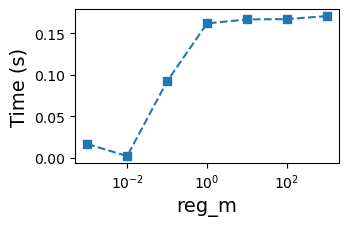

In [323]:
# Importing times
time_path = f"{local_save_dir}section2_sf2_ot_reg_m_times.csv"
times_sf2 = pd.read_csv(time_path, index_col=0).sort_index(ascending=True)
reg_m_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]

# Initialize Figure
fig, ax = plt.subplots(figsize=(3.4, 2))

# Figure Balanced
ax.plot(times_sf2["1 Mb, 95%"].index, times_sf2["1 Mb, 95%"]/n_comparisons, linestyle='--', marker='s')
ax.set_xscale('log')
ax.set_xlabel("reg_m", size=14)
ax.set_ylabel("Time (s)", size=14)
plt.savefig(f"{figure_save_dir}SF4A.pdf", bbox_inches='tight')

### Panel B
Clustermap for reg_m values

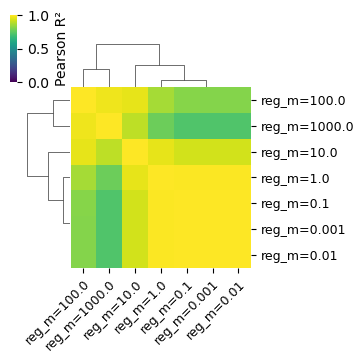

In [325]:
results = import_data_sup2(local_save_dir)
cor_mat = correspondence_matrix(results)
g = sns.clustermap(
    cor_mat,
    cmap="viridis", 
    vmin=0,
    cbar_kws={'label' : 'Pearson R²'},
    figsize=(3.7,3.7),
    cbar_pos=(0, 0.85, 0.02, 0.18)
)

# Label formatting
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Set tick label sizes
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=9)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=9)

# Colorbar size
g.cax.tick_params(labelsize=10)
g.cax.set_ylabel("Pearson R²", fontsize=10)

# Axis Labels
g.ax_heatmap.set_xlabel(g.ax_heatmap.get_xlabel(), fontsize=9)
g.ax_heatmap.set_ylabel(g.ax_heatmap.get_ylabel(), fontsize=9)
plt.savefig(f"{figure_save_dir}SF4B.pdf", bbox_inches='tight')

## Supplementary Figure 3
Histograms of OT costs showing similar distributions for distinct subsets

### Helper Functions

In [32]:
### Helper function for importing data ###
def import_data_sup3(dir: str, balanced: bool=True) -> dict[str, pd.DataFrame]:
    '''
        Imports OT data for section 2, supplementary
        figure 3 as a dictionary with the seed as the key.

        Parameters
        ----------
        dir : str
            Directory to look for files.
        balanced : bool
            Determines whether data to be imported is balanced.
            Default = True.
        
        Returns
        -------
        data_df : dict
            Dictionary containing all dataframes with keys as
            "seed={seed}".
    '''
    # Setting patterns
    if balanced:
        pattern = os.path.join(dir, "balanced_IMMUNE_SF2_res=1_thres=95_count=10_seed=*.csv")
        regex = r"balanced_IMMUNE_SF2_res=1_thres=95_count=10_seed=(?P<seed>.+?)\.csv"
    else:
        pattern = os.path.join(dir, "unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m=0.1_count=10_seed=*.csv")
        regex = r"unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m=0\.1_count=10_seed=(?P<seed>.+?)\.csv"
    
    # Importing
    data_dict = {}
    for filepath in glob.glob(pattern):
        filename = os.path.basename(filepath)
        match = re.search(regex, filename)

        if match:
            seed = match.group("seed")
            data_dict[int(seed)] = pd.read_csv(filepath, index_col=0)
        else:
            print(f"Warning: Could not parse filename: {filename}")

    return data_dict

### Generating Data

In [33]:
### Setting parameters ###
local_save_dir = f"{root}Generated Data/Final Report/Section 2/Supplementary Figure 3/"
seeds = [1, 2, 3, 4, 5]

In [75]:
### Data per seed, balanced ###
for seed in seeds:
    # Subsetting
    subset = subset_clr_data(
        data_dir,
        metadata_df,
        10,
        seed
    )

    # OT and saving
    print(f"OT FOR seed={seed}")
    if not os.path.exists(f"{local_save_dir}balanced_IMMUNE_SF2_res=1_thres=95_count=10_seed={seed}.csv"):
        # OT
        results = hic_ot_optim(
            subset, 
            "chr1",
            selection="threshold",
            norm="sum",
            thres=95,
            thres_type="percentile",
            rebin_factor=1)
        
        results.to_csv(f"{local_save_dir}balanced_IMMUNE_SF2_res=1_thres=95_count=10_seed={seed}.csv")

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x

OT FOR seed=1
OT FOR seed=2


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x

OT FOR seed=3
OT FOR seed=4
OT FOR seed=5


/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [ ]:
### Data per seed, unbalanced ###
for seed in seeds:
    # Subsetting
    subset = subset_clr_data(
        data_dir,
        metadata_df,
        10,
        seed
    )

    # OT and saving
    print(f"OT FOR seed={seed}")
    if not os.path.exists(f"{local_save_dir}unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m=0.1_count=10_seed={seed}.csv"):
        # OT
        results = hic_ot_optim(
            subset, 
            "chr1",
            selection="threshold",
            norm="max",
            unbalanced=0.1,
            thres=95,
            thres_type="percentile",
            rebin_factor=1)
        
        results.to_csv(f"{local_save_dir}unbalanced_IMMUNE_SF2_res=1_thres=95_reg_m=0.1_count=10_seed={seed}.csv")

### Panels

In [34]:
### Loading Data ###
results_subsets_balanced = import_data_sup3(local_save_dir)
results_subsets_unbalanced = import_data_sup3(local_save_dir, False)

In [36]:
results_subsets_balanced[1]

,arc_pair_115785,arc_pair_48468,arc_pair_588363,arc_pair_326215,arc_pair_651331,arc_pair_504056,arc_pair_577714,arc_pair_117464,arc_pair_426966,arc_pair_542791,...,arc_pair_89302,arc_pair_674772,arc_pair_470083,arc_pair_673824,arc_pair_297765,arc_pair_336806,arc_pair_472319,arc_pair_642267,arc_pair_616528,arc_pair_723396
arc_pair_115785,0.000000,2714.795240,1109.683532,441.434902,531.029204,1708.755327,5809.682511,2249.387077,1870.338943,1097.739687,...,2828.056296,2110.262198,1024.478967,1015.606815,5698.144348,4372.186213,825.759048,4277.025727,669.273573,666.779952
arc_pair_48468,2714.795240,0.000000,3331.639803,3359.382303,2407.498636,1511.537983,1698.620992,196.923687,5373.802941,1018.711198,...,325.702637,297.814827,2755.221808,1231.749031,2032.308458,1373.357148,3946.544957,1240.021108,3749.583390,2366.679703
arc_pair_588363,1109.683532,3331.639803,0.000000,961.849310,414.644061,1434.959751,6759.807279,3251.582392,3552.408144,1355.844499,...,3301.774558,2564.091795,541.114688,1604.790178,7282.262299,5741.679976,1701.329160,5450.466136,1151.891337,338.354359
arc_pair_326215,441.434902,3359.382303,961.849310,0.000000,568.343346,2049.765397,6905.870175,2907.234075,1879.760175,1520.055434,...,3526.990423,2714.890375,1042.131444,1497.338096,6775.411530,5272.755925,593.233076,5238.519263,288.669457,728.521694
arc_pair_651331,531.029204,2407.498636,414.644061,568.343346,0.000000,1135.461058,5623.031899,2115.673289,2599.357623,732.234774,...,2554.662364,1776.903703,447.251989,697.012095,5859.155086,4493.682480,1219.883678,4353.409100,887.001665,103.689349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
arc_pair_336806,4372.186213,1373.357148,5741.679976,5272.755925,4493.682480,3207.338909,696.851477,1446.397028,7165.653729,2542.848520,...,1196.202740,1742.192704,4670.617312,2650.093435,334.879249,0.000000,5744.494776,221.087929,5548.811193,4562.644925
arc_pair_472319,825.759048,3946.544957,1701.329160,593.233076,1219.883678,2571.781505,7626.041152,3433.136011,1228.738557,2081.174067,...,4063.979837,3305.426322,1696.228145,2033.028218,7365.215564,5744.494776,0.000000,5739.260687,389.931657,1339.075096
arc_pair_642267,4277.025727,1240.021108,5450.466136,5238.519263,4353.409100,2853.637324,387.666576,1383.087159,7517.078673,2371.824574,...,867.378555,1538.965839,4303.293020,2579.876371,458.435221,221.087929,5739.260687,0.000000,5491.377754,4290.031658
arc_pair_616528,669.273573,3749.583390,1151.891337,288.669457,887.001665,2249.967763,7318.173737,3359.318518,1794.660904,1830.479475,...,3784.936595,3078.578040,1269.302376,1907.278248,7109.370090,5548.811193,389.931657,5491.377754,0.000000,987.271086


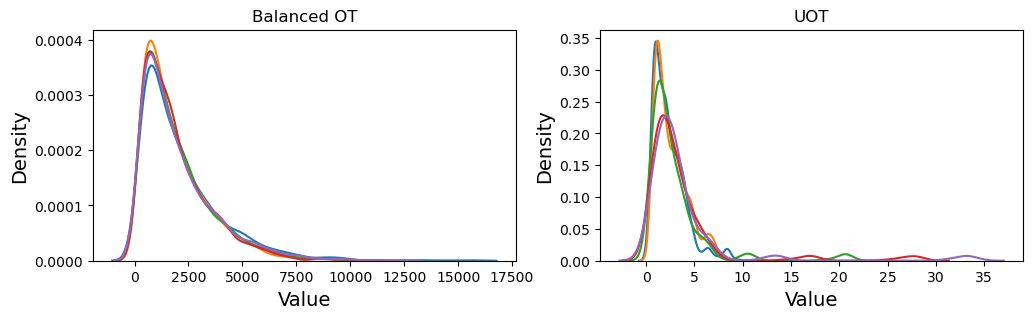

In [13]:
### Figure ###
fig, ax = plt.subplots(1, 2, figsize=(12, 3))

# Panels
for seed in seeds:
    # Extract upper triangle
    matrix_bal = results_subsets_balanced[seed].values
    matrix_unbal = results_subsets_unbalanced[seed].values
    
    idx = np.triu_indices(matrix_bal.shape[0], k=1)
    upper_bal = matrix_bal[idx]
    upper_unbal = matrix_unbal[idx]

    # Balanced
    sns.kdeplot(
        upper_bal,
        ax=ax[0]
    )

    # Unbalanced
    sns.kdeplot(
        upper_unbal,
        ax=ax[1]
    )

# Axis labels
ax[0].set_xlabel("Value", fontsize=14)
ax[1].set_xlabel("Value", fontsize=14)
ax[0].set_ylabel("Density", fontsize=14)
ax[1].set_ylabel("Density", fontsize=14)

# Axis titles
ax[0].set_title("Balanced OT")
ax[1].set_title("UOT")

# Tick labels
for a in ax:
    a.tick_params(axis='both', labelsize=10)

plt.savefig(f"{figure_save_dir}SF5.pdf", bbox_inches='tight')

## Supplementary Figure 4
Violin plots of data before and after trimming outliers.

### Panel A
Before trimming

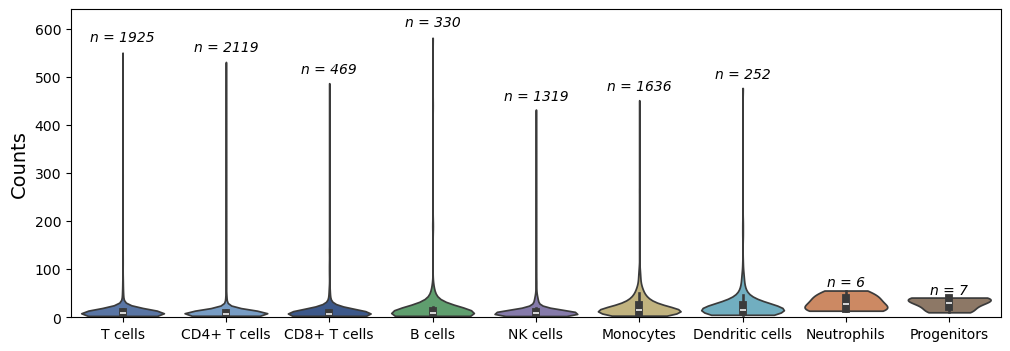

In [345]:
order = [
    "T cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "B cells",
    "NK cells",
    "Monocytes",
    "Dendritic cells",
    "Neutrophils",
    "Progenitors"
]

palette = {
    "T cells": "#4C72B0",          
    "CD4+ T cells": "#6A9BD1",     
    "CD8+ T cells": "#2F5597",     
    "B cells": "#55A868",        
    "NK cells": "#8172B2",        
    "Monocytes": "#CCB974",       
    "Dendritic cells": "#64B5CD", 
    "Neutrophils": "#DD8452",     
    "Progenitors": "#937860"      
}

generate_violin_plot(
    clrs,
    metadata_df,
    fig_size=(12, 4),
    order=order,
    palette=palette
)
plt.savefig(f"{figure_save_dir}SF6A.pdf", bbox_inches='tight')

### Panel B
After trimming

In [340]:
trimmed = subset_clr_data(
    data_dir,
    metadata_df,
    iqr_rule = 1.5
)

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Report Figures/../../Scripts/hicdatautils/hicgeneral.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


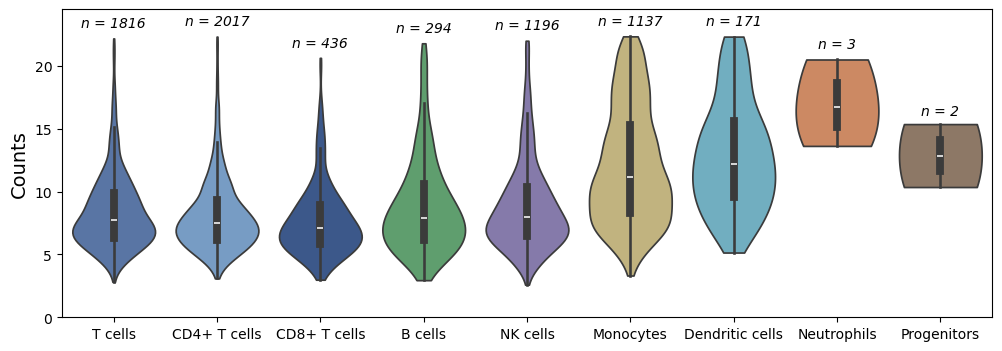

In [346]:
generate_violin_plot(
    trimmed,
    metadata_df,
    fig_size=(12, 4),
    order=order,
    palette=palette
)
plt.savefig(f"{figure_save_dir}SF6B.pdf", bbox_inches='tight')